# Task 3. Visualizations — снижение размерности MNIST

## Цель

В рамках этого задания нужно:

1. загрузить набор MNIST;
2. представить каждую цифру как вектор;
3. преобразовать 784-мерные векторы в 2D;
4. использовать шесть методов:
   - PCA;
   - SVD;
   - Randomized SVD;
   - t-SNE;
   - UMAP;
   - LLE;
5. предложить метрики для сравнения качества разделения классов;
6. визуально и количественно сравнить методы.

### Дополнительно

В этом же ноутбуке предусмотрены:

- сравнение времени работы;
- сравнение Silhouette Score и Davies-Bouldin Index;
- дополнительная оценка через kNN в 2D;
- небольшой подбор `perplexity` для t-SNE;
- сохранение embeddings;
- полноценная секция **Submission** с сохранением PCA-модели, загрузкой модели и проверкой совпадения compressed vector.


# 1. Импорт библиотек

In [1]:
import gzip
import struct
import time
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, LocallyLinearEmbedding
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    accuracy_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.utils.extmath import randomized_svd

try:
    import umap.umap_ as umap
except ImportError as exc:
    raise ImportError(
        "Не найден пакет umap-learn. Установи его в Jupyter: %pip install umap-learn"
    ) from exc

RANDOM_STATE = 42

# Одинаковая выборка для всех методов.
N_VISUALIZATION_SAMPLES = 5000

# Параметры LLE и UMAP.
LLE_NEIGHBORS = 15
UMAP_NEIGHBORS = 15

# Для первого основного запуска t-SNE.
TSNE_PERPLEXITY = 30

np.random.seed(RANDOM_STATE)

print("Окружение подготовлено.")


c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Окружение подготовлено.


# 2. Поиск файлов MNIST

Используем стандартные четыре файла MNIST в формате IDX, сжатые в gzip.


In [2]:
DATA_CANDIDATES = [
    Path("data/MNIST"),
    Path("../data/MNIST"),
    Path("../../data/MNIST"),
]

MNIST_DIR = next(
    (
        path
        for path in DATA_CANDIDATES
        if (path / "train-images-idx3-ubyte.gz").exists()
    ),
    None,
)

if MNIST_DIR is None:
    raise FileNotFoundError(
        "Не найдена папка data/MNIST. Проверь расположение файлов MNIST."
    )

TRAIN_IMAGES = MNIST_DIR / "train-images-idx3-ubyte.gz"
TRAIN_LABELS = MNIST_DIR / "train-labels-idx1-ubyte.gz"
TEST_IMAGES = MNIST_DIR / "t10k-images-idx3-ubyte.gz"
TEST_LABELS = MNIST_DIR / "t10k-labels-idx1-ubyte.gz"

print("MNIST:", MNIST_DIR.resolve())


MNIST: C:\Users\User\Desktop\ML6_Unsupervised_learning_ID_1254805-1\src\data\MNIST


# 3. Загрузка MNIST

Читаем бинарный IDX-формат напрямую, без зависимости от дополнительных библиотек для загрузки MNIST.


In [3]:
def read_idx_images(path: Path) -> np.ndarray:
    with gzip.open(path, "rb") as f:
        magic, n_images, rows, cols = struct.unpack(">IIII", f.read(16))

        if magic != 2051:
            raise ValueError(
                f"Неверный magic number для images: {magic}"
            )

        data = np.frombuffer(f.read(), dtype=np.uint8)

    expected_size = n_images * rows * cols

    if data.size != expected_size:
        raise ValueError(
            f"Ожидалось {expected_size} байт, получено {data.size}"
        )

    return data.reshape(n_images, rows, cols)


def read_idx_labels(path: Path) -> np.ndarray:
    with gzip.open(path, "rb") as f:
        magic, n_labels = struct.unpack(">II", f.read(8))

        if magic != 2049:
            raise ValueError(
                f"Неверный magic number для labels: {magic}"
            )

        data = np.frombuffer(f.read(), dtype=np.uint8)

    if data.size != n_labels:
        raise ValueError(
            f"Ожидалось {n_labels} labels, получено {data.size}"
        )

    return data


X_images_train = read_idx_images(TRAIN_IMAGES)
y_train_full = read_idx_labels(TRAIN_LABELS)

X_images_test = read_idx_images(TEST_IMAGES)
y_test = read_idx_labels(TEST_LABELS)

print("Train images:", X_images_train.shape)
print("Train labels:", y_train_full.shape)
print("Test images:", X_images_test.shape)
print("Test labels:", y_test.shape)


Train images: (60000, 28, 28)
Train labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)


# 4. Первичная проверка MNIST

In [4]:
print("Размер изображения:", X_images_train.shape[1:])
print("Количество train изображений:", len(X_images_train))
print("Количество test изображений:", len(X_images_test))
print("Минимальная интенсивность:", X_images_train.min())
print("Максимальная интенсивность:", X_images_train.max())

assert X_images_train.shape[1:] == (28, 28)
assert len(X_images_train) == len(y_train_full)


Размер изображения: (28, 28)
Количество train изображений: 60000
Количество test изображений: 10000
Минимальная интенсивность: 0
Максимальная интенсивность: 255


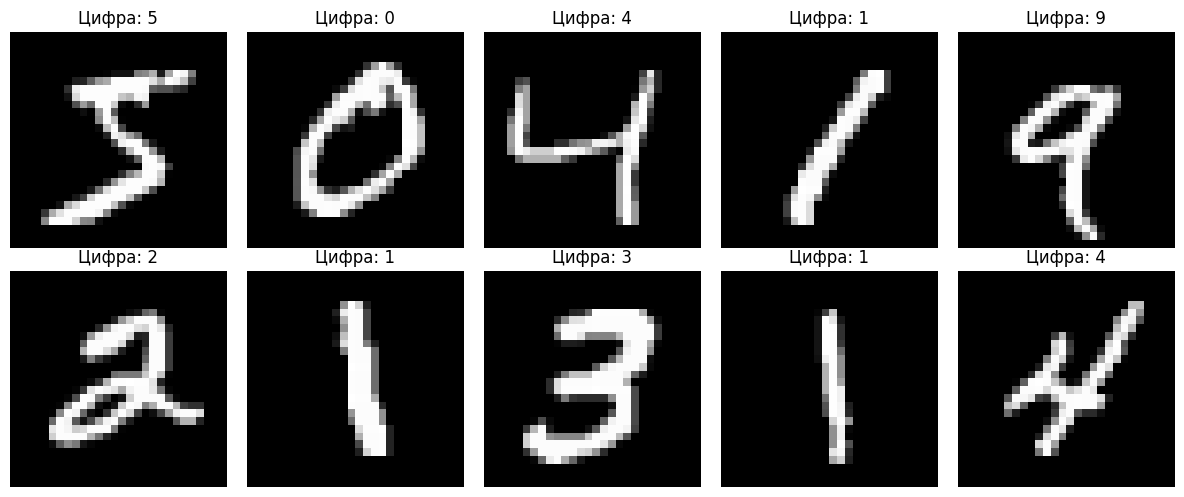

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for ax, image, label in zip(
    axes.ravel(),
    X_images_train[:10],
    y_train_full[:10],
):
    ax.imshow(image, cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"Цифра: {label}")
    ax.axis("off")

plt.tight_layout()
plt.show()


# 5. 28×28 → 784 признака

Каждое изображение разворачиваем в один вектор.

$$
28 	imes 28 = 784
$$

Интенсивности пикселей нормализуем в диапазон `[0, 1]`.


In [6]:
X_train_full = (
    X_images_train
    .reshape(len(X_images_train), -1)
    .astype(np.float32)
    / 255.0
)

print("Размер матрицы признаков:", X_train_full.shape)

assert X_train_full.shape[1] == 784


Размер матрицы признаков: (60000, 784)


# 6. Формирование общей воспроизводимой выборки

Все методы получают **одни и те же изображения**, чтобы сравнение было честным.

Метки `y` не передаются PCA/SVD/t-SNE/UMAP/LLE для построения представления (кроме того, что некоторые методы не используют `y` вообще). Метки используются ниже только для оценки качества разделения классов.


In [7]:
sample_indices, _ = train_test_split(
    np.arange(len(X_train_full)),
    train_size=N_VISUALIZATION_SAMPLES,
    stratify=y_train_full,
    random_state=RANDOM_STATE,
)

X = X_train_full[sample_indices]
y = y_train_full[sample_indices]

print("X:", X.shape)
print("y:", y.shape)

class_distribution = (
    pd.Series(y)
    .value_counts()
    .sort_index()
    .rename("count")
)

display(class_distribution)


X: (5000, 784)
y: (5000,)


0    493
1    562
2    496
3    511
4    487
5    452
6    493
7    522
8    488
9    496
Name: count, dtype: int64

# 7. Центрирование данных для PCA/SVD

PCA работает с центрированными данными. Чтобы корректно сравнить PCA с прямым SVD и Randomized SVD, для трёх линейных методов используем одну и ту же центрированную матрицу.

$$
X_c = X - ar X
$$


In [8]:
X_centered = X - X.mean(axis=0, keepdims=True)

print("Среднее по всем центрированным признакам:")
print(np.abs(X_centered.mean(axis=0)).max())


Среднее по всем центрированным признакам:
4.306543e-06


# 8. Функция оценки 2D embedding

### Основные метрики

**Silhouette Score**

- выше → лучше;
- оценивает компактность объектов внутри классов и разделённость между классами.

**Davies-Bouldin Index**

- ниже → лучше;
- оценивает сходство/перекрытие кластеров.

### Дополнительная метрика

Для дополнительной проверки обучаем простой `kNN` на 2D-представлении. Его accuracy показывает, насколько хорошо compressed representation сохраняет информацию о классе.


In [9]:
def evaluate_embedding(
    name: str,
    embedding: np.ndarray,
    elapsed_seconds: float,
    labels: np.ndarray,
) -> dict:
    silhouette = silhouette_score(
        embedding,
        labels,
        metric="euclidean",
    )

    davies_bouldin = davies_bouldin_score(
        embedding,
        labels,
    )

    return {
        "Method": name,
        "Dimensions": embedding.shape[1],
        "Silhouette": silhouette,
        "Davies-Bouldin": davies_bouldin,
        "Time, sec": elapsed_seconds,
    }


def evaluate_knn_2d(
    embedding: np.ndarray,
    labels: np.ndarray,
    random_state: int = 42,
) -> dict:
    idx_train, idx_test = train_test_split(
        np.arange(len(embedding)),
        test_size=0.25,
        stratify=labels,
        random_state=random_state,
    )

    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(embedding[idx_train], labels[idx_train])

    pred = knn.predict(embedding[idx_test])

    return {
        "kNN accuracy": accuracy_score(labels[idx_test], pred)
    }


# 9. PCA → 2D

In [10]:
start = time.perf_counter()

pca = PCA(
    n_components=2,
    random_state=RANDOM_STATE,
)

X_pca = pca.fit_transform(X)

pca_time = time.perf_counter() - start

pca_result = evaluate_embedding(
    "PCA",
    X_pca,
    pca_time,
    y,
)

pca_knn = evaluate_knn_2d(X_pca, y)
pca_result.update(pca_knn)

print(f"Время: {pca_time:.3f} сек")
print(
    f"Explained variance ratio: "
    f"{pca.explained_variance_ratio_.sum():.4f}"
)
print(f"kNN accuracy: {pca_knn['kNN accuracy']:.4f}")


Время: 0.315 сек
Explained variance ratio: 0.1692
kNN accuracy: 0.3760


# 10. SVD → 2D

Выполняем обычное SVD для центрированной матрицы:

$$
X_c = U\\Sigma V^T
$$

Первые две координаты объектов:

$$
Z_2 = U_2\\Sigma_2
$$


In [11]:
start = time.perf_counter()

U, singular_values, VT = np.linalg.svd(
    X_centered,
    full_matrices=False,
)

X_svd = U[:, :2] * singular_values[:2]

svd_time = time.perf_counter() - start

svd_result = evaluate_embedding(
    "SVD",
    X_svd,
    svd_time,
    y,
)

svd_knn = evaluate_knn_2d(X_svd, y)
svd_result.update(svd_knn)

print(f"Время: {svd_time:.3f} сек")
print(
    f"Explained energy by 2 components: "
    f"{np.sum(singular_values[:2] ** 2) / np.sum(singular_values ** 2):.4f}"
)
print(f"kNN accuracy: {svd_knn['kNN accuracy']:.4f}")


Время: 6.876 сек
Explained energy by 2 components: 0.1692
kNN accuracy: 0.3760


# 11. Randomized SVD → 2D

Используем случайный алгоритм SVD для получения двух главных компонент.

Фиксируем `random_state`, чтобы результат был воспроизводимым.


In [12]:
start = time.perf_counter()

Ur, sr, VTr = randomized_svd(
    X_centered,
    n_components=2,
    n_iter=7,
    random_state=RANDOM_STATE,
)

X_randomized_svd = Ur * sr

randomized_svd_time = time.perf_counter() - start

randomized_svd_result = evaluate_embedding(
    "Randomized SVD",
    X_randomized_svd,
    randomized_svd_time,
    y,
)

randomized_svd_knn = evaluate_knn_2d(
    X_randomized_svd,
    y,
)
randomized_svd_result.update(randomized_svd_knn)

print(f"Время: {randomized_svd_time:.3f} сек")
print(f"kNN accuracy: {randomized_svd_knn['kNN accuracy']:.4f}")


Время: 0.032 сек
kNN accuracy: 0.3760


# 12. t-SNE → 2D

t-SNE ищет двумерное представление, сохраняющее структуру соседств.

Здесь `y` не используется для обучения embedding.


In [13]:
start = time.perf_counter()

tsne = TSNE(
    n_components=2,
    perplexity=TSNE_PERPLEXITY,
    init="pca",
    learning_rate="auto",
    max_iter=1000,
    random_state=RANDOM_STATE,
)

X_tsne = tsne.fit_transform(X)

tsne_time = time.perf_counter() - start

tsne_result = evaluate_embedding(
    "t-SNE",
    X_tsne,
    tsne_time,
    y,
)

tsne_knn = evaluate_knn_2d(X_tsne, y)
tsne_result.update(tsne_knn)

print(f"Время: {tsne_time:.3f} сек")
print(f"kNN accuracy: {tsne_knn['kNN accuracy']:.4f}")


Время: 20.964 сек
kNN accuracy: 0.9112


# 13. UMAP → 2D

UMAP использует локальную структуру ближайших соседей и строит нелинейное двумерное представление.


In [14]:
start = time.perf_counter()

umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=UMAP_NEIGHBORS,
    min_dist=0.1,
    metric="euclidean",
    random_state=RANDOM_STATE,
)

X_umap = umap_model.fit_transform(X)

umap_time = time.perf_counter() - start

umap_result = evaluate_embedding(
    "UMAP",
    X_umap,
    umap_time,
    y,
)

umap_knn = evaluate_knn_2d(X_umap, y)
umap_result.update(umap_knn)

print(f"Время: {umap_time:.3f} сек")
print(f"kNN accuracy: {umap_knn['kNN accuracy']:.4f}")


c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Время: 43.254 сек
kNN accuracy: 0.9200


# 14. LLE → 2D

LLE сохраняет локальные линейные отношения между каждой точкой и её ближайшими соседями.


In [15]:
start = time.perf_counter()

lle = LocallyLinearEmbedding(
    n_neighbors=LLE_NEIGHBORS,
    n_components=2,
    method="standard",
    eigen_solver="auto",
    random_state=RANDOM_STATE,
)

X_lle = lle.fit_transform(X)

lle_time = time.perf_counter() - start

lle_result = evaluate_embedding(
    "LLE",
    X_lle,
    lle_time,
    y,
)

lle_knn = evaluate_knn_2d(X_lle, y)
lle_result.update(lle_knn)

print(f"Время: {lle_time:.3f} сек")
print(f"kNN accuracy: {lle_knn['kNN accuracy']:.4f}")


Время: 25.669 сек
kNN accuracy: 0.5040


# 15. Сводная таблица результатов

Здесь сравниваем:

- Silhouette — больше лучше;
- Davies-Bouldin — меньше лучше;
- kNN accuracy — больше лучше;
- время — меньше лучше.


In [16]:
results = pd.DataFrame([
    pca_result,
    svd_result,
    randomized_svd_result,
    tsne_result,
    umap_result,
    lle_result,
])

display(
    results.sort_values(
        "Silhouette",
        ascending=False,
    ).round({
        "Silhouette": 4,
        "Davies-Bouldin": 4,
        "kNN accuracy": 4,
        "Time, sec": 3,
    })
)


,Method,Dimensions,Silhouette,Davies-Bouldin,"Time, sec",kNN accuracy
4,UMAP,2,0.3635,1.3733,43.254,0.9200
3,t-SNE,2,0.3068,2.1774,20.964,0.9112
1,SVD,2,0.0149,6.3216,6.876,0.3760
0,PCA,2,0.0149,6.3217,0.315,0.3760
2,Randomized SVD,2,0.0149,6.3217,0.032,0.3760
5,LLE,2,-0.0555,9.7593,25.669,0.5040


# 16. Визуализация всех шести методов

Метки цифр используются только для окраски точек. Само отображение строилось без передачи `y`.


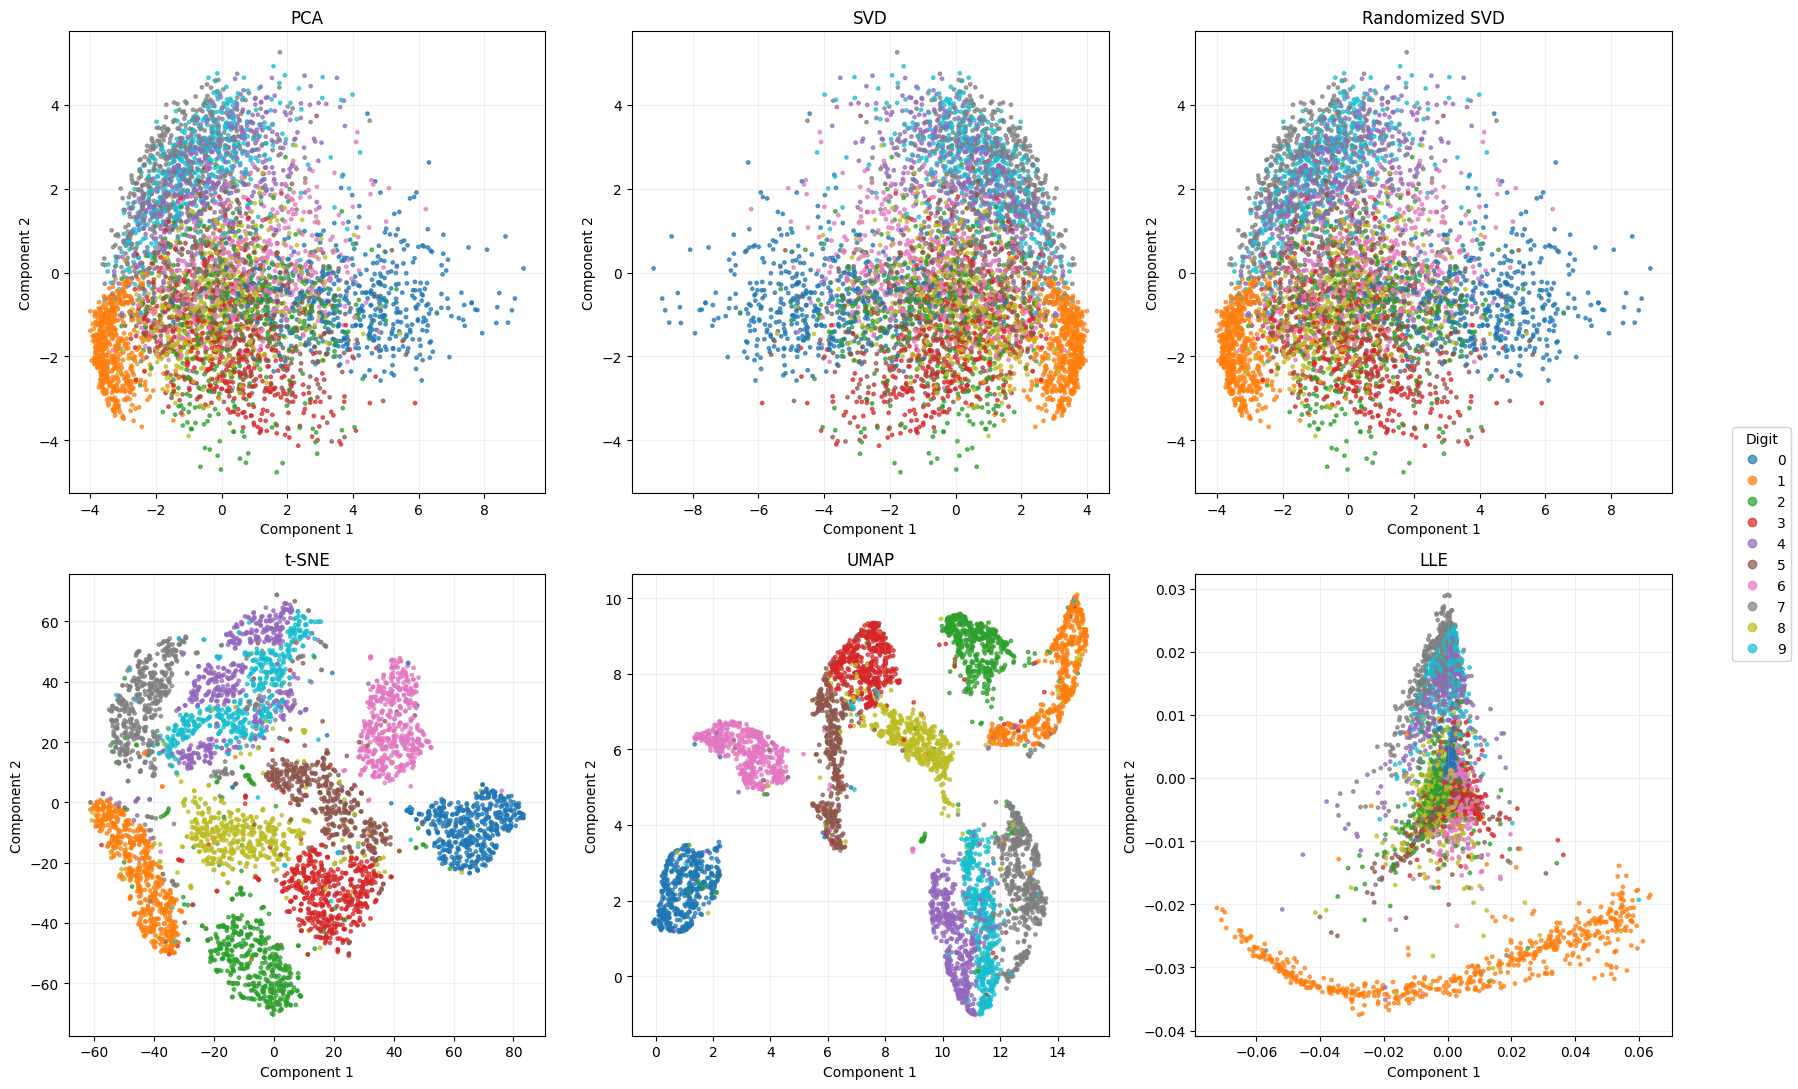

In [17]:
embeddings = {
    "PCA": X_pca,
    "SVD": X_svd,
    "Randomized SVD": X_randomized_svd,
    "t-SNE": X_tsne,
    "UMAP": X_umap,
    "LLE": X_lle,
}

fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 11),
)

for ax, (name, embedding) in zip(
    axes.ravel(),
    embeddings.items(),
):
    scatter = ax.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=y,
        cmap="tab10",
        s=6,
        alpha=0.7,
    )

    ax.set_title(name)
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")
    ax.grid(alpha=0.2)

handles, _ = scatter.legend_elements()
fig.legend(
    handles,
    [str(i) for i in range(10)],
    title="Digit",
    loc="center right",
)

plt.tight_layout(rect=(0, 0, 0.94, 1))
plt.show()


# 17. Silhouette Score

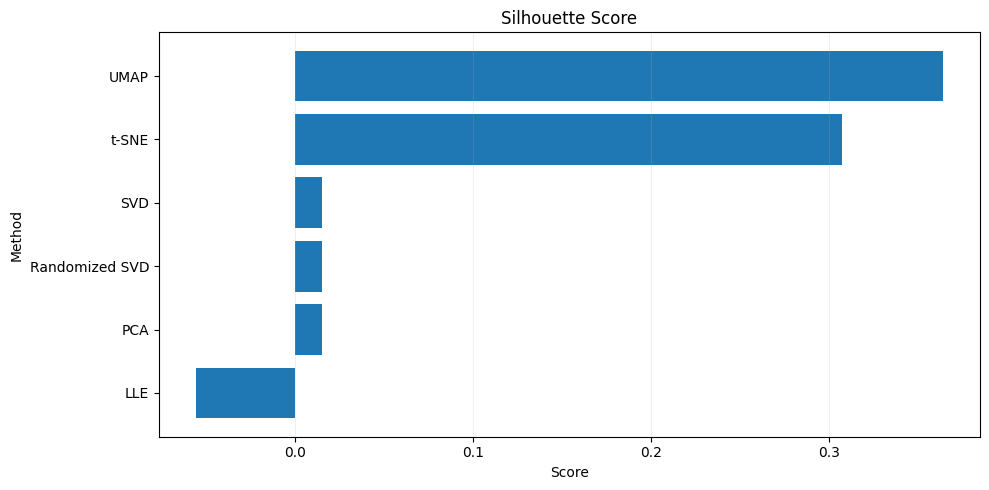

In [18]:
silhouette_results = results.sort_values(
    "Silhouette",
    ascending=True,
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.barh(
    silhouette_results["Method"],
    silhouette_results["Silhouette"],
)

ax.set_title("Silhouette Score")
ax.set_xlabel("Score")
ax.set_ylabel("Method")
ax.grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.show()


# 18. Davies-Bouldin Index

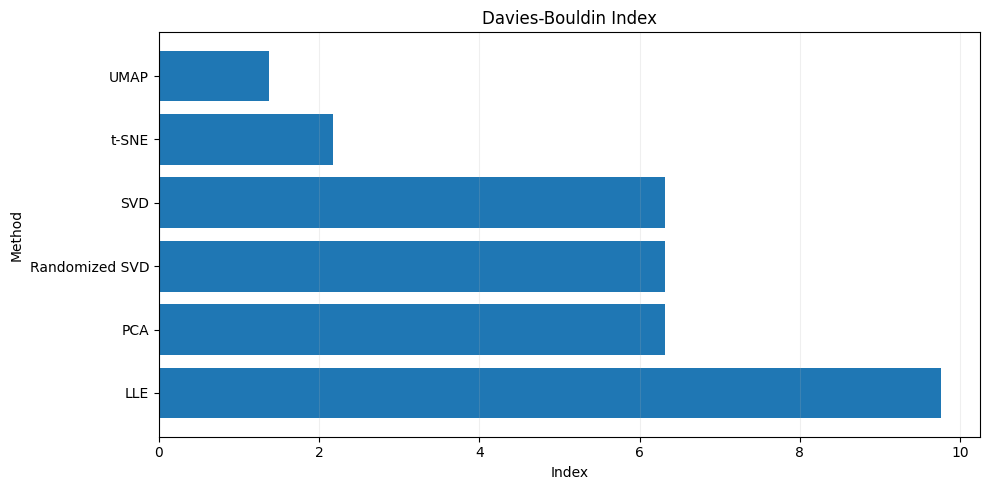

In [19]:
db_results = results.sort_values(
    "Davies-Bouldin",
    ascending=False,
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.barh(
    db_results["Method"],
    db_results["Davies-Bouldin"],
)

ax.set_title("Davies-Bouldin Index")
ax.set_xlabel("Index")
ax.set_ylabel("Method")
ax.grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.show()


# 19. kNN accuracy в 2D

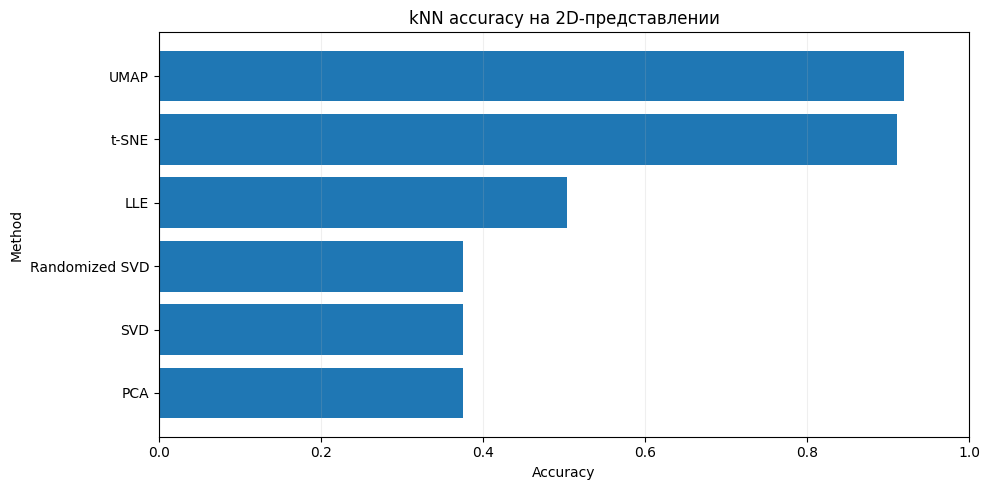

In [20]:
knn_results = results.sort_values(
    "kNN accuracy",
    ascending=True,
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.barh(
    knn_results["Method"],
    knn_results["kNN accuracy"],
)

ax.set_title("kNN accuracy на 2D-представлении")
ax.set_xlabel("Accuracy")
ax.set_ylabel("Method")
ax.set_xlim(0, 1)
ax.grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.show()


# 20. Время работы

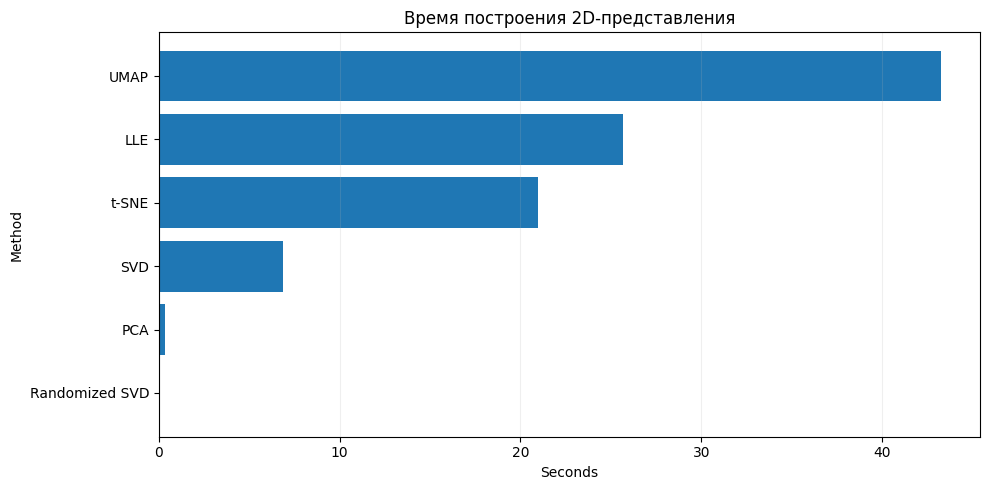

In [21]:
time_results = results.sort_values(
    "Time, sec",
    ascending=True,
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.barh(
    time_results["Method"],
    time_results["Time, sec"],
)

ax.set_title("Время построения 2D-представления")
ax.set_xlabel("Seconds")
ax.set_ylabel("Method")
ax.grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.show()


# 21. Дополнительный эксперимент: подбор perplexity для t-SNE

По чек-листу ожидается, что t-SNE даст очень хороший результат. Однако качество t-SNE зависит от параметров.

Проверим несколько значений `perplexity`:

- 10;
- 30;
- 50.

Это дополнительный эксперимент. Все остальные параметры и выборка остаются одинаковыми.


In [22]:
TSNE_PERPLEXITIES = [10, 30, 50]

tsne_tuning_rows = []
tsne_tuning_embeddings = {}

for perplexity in TSNE_PERPLEXITIES:
    start = time.perf_counter()

    model = TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        learning_rate="auto",
        max_iter=1000,
        random_state=RANDOM_STATE,
    )

    embedding = model.fit_transform(X)

    elapsed = time.perf_counter() - start

    metrics = evaluate_embedding(
        f"t-SNE p={perplexity}",
        embedding,
        elapsed,
        y,
    )

    knn = evaluate_knn_2d(embedding, y)
    metrics.update(knn)

    tsne_tuning_rows.append(metrics)
    tsne_tuning_embeddings[perplexity] = embedding

tsne_tuning_results = pd.DataFrame(tsne_tuning_rows)

display(
    tsne_tuning_results.round({
        "Silhouette": 4,
        "Davies-Bouldin": 4,
        "kNN accuracy": 4,
        "Time, sec": 3,
    })
)


,Method,Dimensions,Silhouette,Davies-Bouldin,"Time, sec",kNN accuracy
0,t-SNE p=10,2,0.3084,1.7729,32.344,0.9192
1,t-SNE p=30,2,0.3068,2.1774,16.558,0.9112
2,t-SNE p=50,2,0.2767,4.1515,41.864,0.8968


## 22. Лучший вариант t-SNE по Silhouette

In [23]:
best_tsne_row = tsne_tuning_results.loc[
    tsne_tuning_results["Silhouette"].idxmax()
]

best_tsne_perplexity = int(
    str(best_tsne_row["Method"]).split("=")[1]
)

X_tsne_best = tsne_tuning_embeddings[best_tsne_perplexity]

print(
    f"Лучший perplexity по Silhouette: "
    f"{best_tsne_perplexity}"
)

display(best_tsne_row.to_frame().T.round({
    "Silhouette": 4,
    "Davies-Bouldin": 4,
    "kNN accuracy": 4,
    "Time, sec": 3,
}))


Лучший perplexity по Silhouette: 10


,Method,Dimensions,Silhouette,Davies-Bouldin,"Time, sec",kNN accuracy
0,t-SNE p=10,2,0.308377,1.772865,32.34427,0.9192


# 23. Сравнение t-SNE до и после настройки

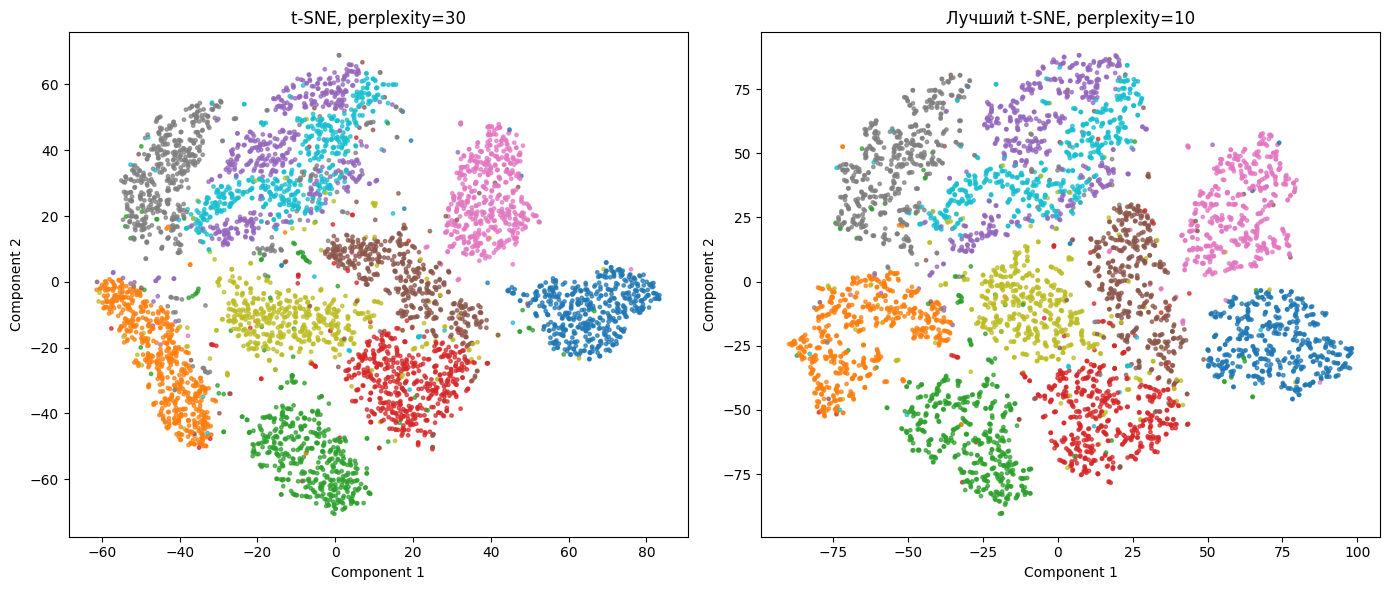

In [24]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6),
)

axes[0].scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y,
    cmap="tab10",
    s=6,
    alpha=0.7,
)

axes[0].set_title(
    f"t-SNE, perplexity={TSNE_PERPLEXITY}"
)
axes[0].set_xlabel("Component 1")
axes[0].set_ylabel("Component 2")

axes[1].scatter(
    X_tsne_best[:, 0],
    X_tsne_best[:, 1],
    c=y,
    cmap="tab10",
    s=6,
    alpha=0.7,
)

axes[1].set_title(
    f"Лучший t-SNE, perplexity={best_tsne_perplexity}"
)
axes[1].set_xlabel("Component 1")
axes[1].set_ylabel("Component 2")

plt.tight_layout()
plt.show()


# 24. Финальная таблица с лучшим t-SNE

В основной таблице заменяем первоначальный t-SNE на лучший найденный вариант только для аналитического сравнения.

Это не изменяет остальные методы.


In [25]:
best_tsne_analysis = evaluate_embedding(
    "t-SNE (best perplexity)",
    X_tsne_best,
    float(best_tsne_row["Time, sec"]),
    y,
)

best_tsne_analysis["kNN accuracy"] = float(
    best_tsne_row["kNN accuracy"]
)

final_results = pd.DataFrame([
    pca_result,
    svd_result,
    randomized_svd_result,
    best_tsne_analysis,
    umap_result,
    lle_result,
])

display(
    final_results.sort_values(
        "Silhouette",
        ascending=False,
    ).round({
        "Silhouette": 4,
        "Davies-Bouldin": 4,
        "kNN accuracy": 4,
        "Time, sec": 3,
    })
)


,Method,Dimensions,Silhouette,Davies-Bouldin,"Time, sec",kNN accuracy
4,UMAP,2,0.3635,1.3733,43.254,0.9200
3,t-SNE (best perplexity),2,0.3084,1.7729,32.344,0.9192
1,SVD,2,0.0149,6.3216,6.876,0.3760
0,PCA,2,0.0149,6.3217,0.315,0.3760
2,Randomized SVD,2,0.0149,6.3217,0.032,0.3760
5,LLE,2,-0.0555,9.7593,25.669,0.5040


# 25. Автоматическое определение победителей

Определяем лучший метод по каждой метрике отдельно.

Не следует смешивать эти критерии в один без объяснения: один метод может быть лучшим по Silhouette, другой — по скорости.


In [26]:
best_silhouette = final_results.loc[
    final_results["Silhouette"].idxmax()
]

best_db = final_results.loc[
    final_results["Davies-Bouldin"].idxmin()
]

best_knn = final_results.loc[
    final_results["kNN accuracy"].idxmax()
]

fastest = final_results.loc[
    final_results["Time, sec"].idxmin()
]

print(
    "Лучший по Silhouette:",
    best_silhouette["Method"],
    f"({best_silhouette['Silhouette']:.4f})",
)

print(
    "Лучший по Davies-Bouldin:",
    best_db["Method"],
    f"({best_db['Davies-Bouldin']:.4f})",
)

print(
    "Лучший по kNN accuracy:",
    best_knn["Method"],
    f"({best_knn['kNN accuracy']:.4f})",
)

print(
    "Самый быстрый:",
    fastest["Method"],
    f"({fastest['Time, sec']:.4f} сек)",
)


Лучший по Silhouette: UMAP (0.3635)
Лучший по Davies-Bouldin: UMAP (1.3733)
Лучший по kNN accuracy: UMAP (0.9200)
Самый быстрый: Randomized SVD (0.0324 сек)


# 26. Сохранение embeddings

Сохраняем полученные 2D embeddings и итоговую таблицу. Это удобно для анализа без повторного запуска дорогих методов.


In [27]:
PROCESSED_DIR = MNIST_DIR.parent / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Основной набор embeddings.
embedding_files = {
    "pca": X_pca,
    "svd": X_svd,
    "randomized_svd": X_randomized_svd,
    "tsne": X_tsne,
    "tsne_best": X_tsne_best,
    "umap": X_umap,
    "lle": X_lle,
}

for name, embedding in embedding_files.items():
    np.save(
        PROCESSED_DIR / f"mnist_{name}_2d.npy",
        embedding,
    )

np.save(
    PROCESSED_DIR / "mnist_labels_5000.npy",
    y,
)

final_results.to_csv(
    PROCESSED_DIR / "mnist_dimensionality_reduction_results.csv",
    index=False,
)

print(
    "Embeddings и таблица сохранены в:",
    PROCESSED_DIR.resolve(),
)


Embeddings и таблица сохранены в: C:\Users\User\Desktop\ML6_Unsupervised_learning_ID_1254805-1\src\data\processed


# 27. Итоговые выводы по Task 3

В выводе необходимо сравнить методы по трём группам критериев:

### Качество разделения

- высокий Silhouette — хорошо;
- низкий Davies-Bouldin — хорошо;
- высокая kNN accuracy в 2D означает, что compressed representation хорошо сохраняет информацию о цифрах.

### Визуальное качество

t-SNE и UMAP, как нелинейные методы, обычно способны получить более компактные и визуально разделённые группы, чем линейные PCA/SVD.

### Вычислительная стоимость

PCA и SVD обычно существенно дешевле нелинейных методов. t-SNE, UMAP и LLE требуют больше вычислений.

При этом окончательный вывод должен основываться на **фактических результатах запуска**, а не на заранее заданном ожидании.


# 28. Submission

## Сохранение одной модели из Visualizations

Для Submission сохраняем **PCA-модель**, обученную в этом ноутбуке.

Почему PCA:

- модель легко сериализуется;
- `transform()` принимает обычный 784-мерный вектор;
- результат двумерный;
- получение одинакового compressed vector легко проверить.

Требование Submission: другой студент должен загрузить сохранённую модель и использовать её для сжатия рукописной цифры, причём результат должен совпадать.


In [28]:
SUBMISSION_DIR = MNIST_DIR.parent.parent / "submission"
SUBMISSION_DIR.mkdir(parents=True, exist_ok=True)

PCA_MODEL_PATH = SUBMISSION_DIR / "mnist_pca_2d.joblib"

joblib.dump(
    pca,
    PCA_MODEL_PATH,
)

print("PCA сохранена:")
print(PCA_MODEL_PATH.resolve())


PCA сохранена:
C:\Users\User\Desktop\ML6_Unsupervised_learning_ID_1254805-1\src\submission\mnist_pca_2d.joblib


# 29. Сохраняем контрольную цифру

Сохраняем одну конкретную MNIST-цифру и полученный для неё compressed vector.

Это позволяет peer быстро проверить, что загруженная модель работает точно так же.


In [29]:
REFERENCE_DIGIT_PATH = SUBMISSION_DIR / "reference_digit.npy"
REFERENCE_VECTOR_PATH = SUBMISSION_DIR / "reference_compressed_vector.npy"
REFERENCE_LABEL_PATH = SUBMISSION_DIR / "reference_label.npy"

reference_digit = X[0].copy()
reference_label = np.array([y[0]], dtype=np.uint8)

reference_vector = pca.transform(
    reference_digit.reshape(1, -1)
)[0]

np.save(
    REFERENCE_DIGIT_PATH,
    reference_digit,
)

np.save(
    REFERENCE_VECTOR_PATH,
    reference_vector,
)

np.save(
    REFERENCE_LABEL_PATH,
    reference_label,
)

print("Контрольная цифра:", int(reference_label[0]))
print("Compressed vector:", reference_vector)


Контрольная цифра: 1
Compressed vector: [-3.6671333 -2.464532 ]


# 30. Проверяем загрузку сохранённой модели

Очень важный этап: не просто сохранить файл, а загрузить его обратно и проверить, что результат не изменился.


In [31]:
loaded_pca = joblib.load(PCA_MODEL_PATH)

loaded_vector = loaded_pca.transform(
    reference_digit.reshape(1, -1)
)[0]

print("Оригинальный vector:")
print(reference_vector)

print("\nVector после загрузки модели:")
print(loaded_vector)

np.testing.assert_allclose(
    reference_vector,
    loaded_vector,
    rtol=1e-5,
    atol=1e-5,
)

print("\nПроверка пройдена: compressed vectors совпадают.")


Оригинальный vector:
[-3.6671333 -2.464532 ]

Vector после загрузки модели:
[-3.6671343 -2.4645312]

Проверка пройдена: compressed vectors совпадают.


# 31. Код для peer review

Ниже находится минимальный независимый пример, который можно использовать при проверке проекта.

Предполагается, что:

- `mnist_pca_2d.joblib` — сохранённая модель;
- `reference_digit.npy` — одна цифра в формате 784 признаков.

Логика:

`784 → PCA → 2`.


In [32]:
import joblib
import numpy as np

# Загружаем сохранённую PCA-модель.
pca = joblib.load("submission/mnist_pca_2d.joblib")

# Загружаем одну заранее сохранённую MNIST-цифру.
digit = np.load("submission/reference_digit.npy")

# Преобразуем 784 признака в 2 компоненты.
compressed_vector = pca.transform(
    digit.reshape(1, -1)
)[0]

print("Compressed vector:")
print(compressed_vector)


Compressed vector:
[-3.6671343 -2.4645312]


# 32. Проверка expected result

Можно сравнить результат peer с заранее сохранённым compressed vector.


In [34]:
expected_vector = np.load(
    "submission/reference_compressed_vector.npy"
)

np.testing.assert_allclose(
    reference_vector,
    loaded_vector,
    rtol=1e-5,
    atol=1e-5,
)

print("Expected result совпадает с полученным vector.")
print(expected_vector)


Expected result совпадает с полученным vector.
[-3.6671333 -2.464532 ]


# 33. Структура Submission

После выполнения этого раздела в папке `src/submission/` должны появиться:

```text
submission/
├── mnist_pca_2d.joblib
├── reference_digit.npy
├── reference_compressed_vector.npy
└── reference_label.npy
```

А основной проект содержит пять ноутбуков:

```text
Task_1.ipynb
Task_2.ipynb
Task_3.ipynb
Task_4.ipynb
Task_5.ipynb
```

Submission является частью `Task_3.ipynb`, потому что сохраняется модель именно из раздела Visualizations.


# Контрольный список Task 3 + Submission

## Task 3

- [x] MNIST загружен
- [x] изображения представлены как векторы
- [x] 28×28 → 784
- [x] PCA → 2D
- [x] SVD → 2D
- [x] Randomized SVD → 2D
- [x] t-SNE → 2D
- [x] UMAP → 2D
- [x] LLE → 2D
- [x] визуализация всех методов
- [x] Silhouette Score
- [x] Davies-Bouldin Index
- [x] kNN accuracy
- [x] время работы
- [x] подбор perplexity для t-SNE
- [x] сохранение embeddings
- [x] итоговое сравнение

## Submission

- [x] сохранена модель из Visualizations
- [x] модель загружается обратно
- [x] есть пример применения
- [x] сохранена контрольная цифра
- [x] сохранён expected compressed vector
- [x] проверено совпадение результатов после загрузки
- [x] подготовлен минимальный код для peer review
